In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
sulyok = np.array([0.15, 0.20, 0.25, 0.30, 0.35])
henger_gyorsulasok = [[0.0008, 0.0008, 0.0007], [0.0011, 0.0012, 0.0011], [0.0015, 0.0015, 0.0015], [0.0019, 0.0018, 0.0018], [0.0022, 0.0022, 0.0022]]
rud_gyosrulasok = [[0.0041, 0.0042, 0.0042], [0.0055, 0.0055, 0.0055], [0.0068, 0.0070, 0.0069], [0.0084, 0.0084, 0.0084], [0.0098, 0.0098, 0.0097]]
henger_tarcsa_sugar = 0.0049 / 2
rud_tarcsa_sugar = 0.0051 / 2
g = 9.81

In [4]:
henger_atlagok = np.array([np.average(i) for i in henger_gyorsulasok])
rud_atlagok = np.array([np.average(i) for i in rud_gyosrulasok])
henger_szoggyorsulas_atlag = henger_atlagok / henger_tarcsa_sugar
rud_szoggyorulas_atlag = rud_atlagok / rud_tarcsa_sugar

In [5]:
henger_y_adatok = sulyok * henger_tarcsa_sugar * (g - henger_tarcsa_sugar * henger_szoggyorsulas_atlag)
rud_y_adatok = sulyok * rud_tarcsa_sugar * (g - rud_tarcsa_sugar * rud_szoggyorulas_atlag)
def y(x, th, m_s):
    return (th * x + m_s)

In [6]:
henger_parameterek, henger_hibak = curve_fit(y, henger_szoggyorsulas_atlag, henger_y_adatok) 
rud_parameterek, rud_hibak = curve_fit(y, rud_szoggyorulas_atlag, rud_y_adatok)
print(henger_parameterek)
print(rud_parameterek)

[0.00824993 0.00100155]
[2.25800922e-03 9.78565978e-05]


In [7]:
a = 1/2*1.511 * (0.2195 / 2) **2
print(a)
b = 1/12*0.223*(0.359)**2 + 1/4*0.223*(0.01005 / 2)**2
print(b)

0.00910004471875
0.0023964463056770835


In [8]:
for i in range(5):
    print(y(henger_szoggyorsulas_atlag[i], henger_parameterek[0], henger_parameterek[1]))
    print(henger_y_adatok[i])
    print()

0.003583157275634504
0.00360489325

0.0048178409485334995
0.004806344666666667

0.006052524621432494
0.00600770625

0.007174964324067943
0.0072090025

0.008409647996966939
0.008410188499999999



In [17]:
for i in range(5):
    print(sulyok[i], end=" & ")
    print(rud_y_adatok[i], end=" & ")
    print(rud_szoggyorulas_atlag[i], end=" ")
    print("\\\\")

0.15 & 0.0037507312500000005 & 1.6339869281045751 \\
0.2 & 0.005000295000000001 & 2.156862745098039 \\
0.25 & 0.006249476250000001 & 2.705882352941176 \\
0.3 & 0.007498224000000001 & 3.294117647058823 \\
0.35 & 0.00874670825 & 3.830065359477124 \\


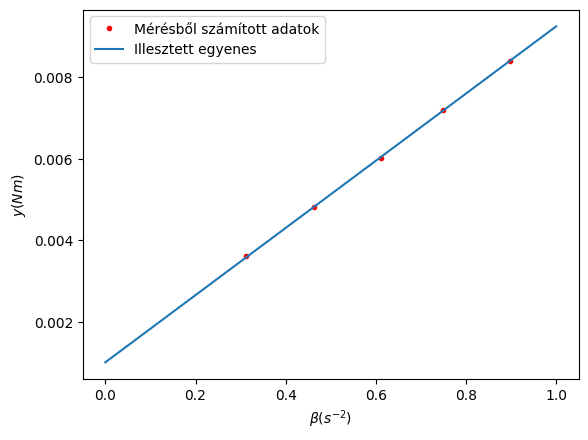

In [22]:
plt.plot(henger_szoggyorsulas_atlag, henger_y_adatok, "r.", label="Mérésből számított adatok")
plt.plot(np.linspace(0,1, 100), y(np.linspace(0,1, 100), henger_parameterek[0], henger_parameterek[1]), label="Illesztett egyenes")
plt.xlabel("$\\beta(s^{-2})$")
plt.ylabel("$y(Nm)$")
plt.legend()
plt.show()

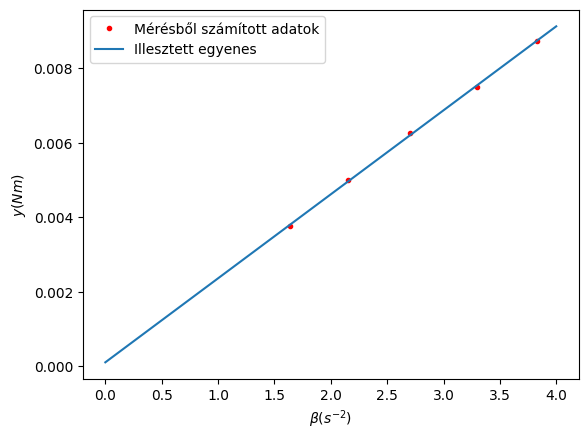

In [24]:

plt.plot(rud_szoggyorulas_atlag, rud_y_adatok, "r.", label="Mérésből számított adatok")
plt.plot(np.linspace(0,4, 100), y(np.linspace(0,4, 100), rud_parameterek[0], rud_parameterek[1]), label="Illesztett egyenes")
plt.xlabel("$\\beta(s^{-2})$")
plt.ylabel("$y(Nm)$")
plt.legend()
plt.show()